In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


we'll now load our dataset and reset index (we want for each hour, data is for 10 min stamps)

In [3]:
df = pd.read_csv('/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv')

# Use every 6th row (data is recorded every 10 mins, we want hourly)
df = df[5::6].reset_index(drop=True)

# Select features
features = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'wd (deg)']
data = df[features].values.astype(np.float32)

# Normalize
mean = data.mean(axis=0)
std = data.std(axis=0)
data = (data - mean) / std

# Save temperature mean/std for inverse transform later
temp_mean = mean[0]
temp_std = std[0]

print(f'Dataset shape: {data.shape}')
print(f'Features: {features}')

Dataset shape: (70091, 5)
Features: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'wd (deg)']


# Create Sliding Window Dataset
Each sample consists of 720 hours of input observations and 24 hours of future temperature values as the target. The dataset class handles creating these windows automatically, and the data is split chronologically into 70% train, 15% val, 15% test. since this is a time series, we'll have to make sure that the splitting is done chronologically.

In [4]:
class ClimateDataset(Dataset):
    def __init__(self, data, input_len=720, output_len=24):
        self.data = data
        self.input_len = input_len
        self.output_len = output_len

    def __len__(self):
        return len(self.data) - self.input_len - self.output_len + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.input_len]
        y = self.data[idx + self.input_len : idx + self.input_len + self.output_len, 0]  # temperature only
        return torch.tensor(x), torch.tensor(y)

# Chronological split
n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

train_dataset = ClimateDataset(train_data)
val_dataset = ClimateDataset(val_data)
test_dataset = ClimateDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples:   {len(val_dataset)}')
print(f'Test samples:  {len(test_dataset)}')

Train samples: 48320
Val samples:   9771
Test samples:  9771


# Sinusoidal Positional Encoding
Since self-attention processes all timesteps simultaneously with no sense of order, positional encoding adds a unique position fingerprint to each timestep. Even and odd dimensions of the embedding get sine and cosine waves of different frequencies respectively. This is computed once and added to the input embeddings before passing into the encoder.

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=720, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)  # even indices → sin
        pe[:, 1::2] = torch.cos(position * div_term)  # odd indices → cos

        pe = pe.unsqueeze(0)  # (1, max_len, d_model) for batch broadcasting
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

Multi-Head Self Attention
Each timestep creates Q, K and V values. Attention scores are computed by comparing every Q against every K, scaled by sqrt(d_k) to prevent large values, then normalized via softmax. The scores are used to take a weighted sum of values
giving each timestep a new representation that has gathered information from the most relevant other timesteps. Multiple heads run in parallel, each learning to attend to different patterns, and their outputs are concatenated and projected back to d_model.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # dimension per head

        # Linear projections for Q, K, V and output
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V):#relevance of each vector to other
        # Q, K, V shape: (batch, heads, seq_len, d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)#scores are calculated and then scaled down to prevent from becoming to large
        attention_weights = torch.softmax(scores, dim=-1)#normalised to convert into probability distribution
        output = torch.matmul(attention_weights, V)
        return output

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        # Project to Q, K, V
        Q = self.W_q(x)  # (batch, seq_len, d_model)
        K = self.W_k(x)
        V = self.W_v(x)

        # Split into heads where each head independantly 
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)  # (batch, heads, seq_len, d_k)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # Attention per head
        attn_output = self.scaled_dot_product_attention(Q, K, V)  # (batch, heads, seq_len, d_k)

        # Concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

        # Final linear projection
        output = self.W_o(attn_output)
        return output

Feed forward:
After attention has gathered information from other timesteps, each timestep's representation passes through a small 2-layer network independently. It expands to 4×d_model (256 dimensions) with ReLU non-linearity, then projects back to d_model (64). This adds non-linearity and lets the model process each position's attended representation further.

In [7]:
class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super(FeedForward, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(EncoderBlock, self).__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ff = FeedForward(d_model, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Self attention + residual + norm
        attn_output = self.attention(x)
        x = self.norm1(x + self.dropout(attn_output))

        # Feed forward + residual + norm
        ff_output = self.ff(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [9]:
class TransformerForecaster(nn.Module):
    def __init__(self, input_dim, d_model=64, num_heads=4, num_layers=3, output_len=24, dropout=0.1):
        super(TransformerForecaster, self).__init__()

        # Project input features to d_model
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_len=720, dropout=dropout)

        # Stack of encoder blocks
        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, dropout)
            for _ in range(num_layers)
        ])

        # Output head
        self.output_layer = nn.Linear(d_model, output_len)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)

        # Project to d_model
        x = self.input_projection(x)  # (batch, seq_len, d_model)

        # Add positional encoding
        x = self.pos_encoding(x)

        # Pass through encoder blocks
        for block in self.encoder_blocks:
            x = block(x)

        # Global average pooling across timesteps
        x = x.mean(dim=1)  # (batch, d_model)

        # Output projection
        out = self.output_layer(x)  # (batch, 24)
        return out

# Instantiate model
input_dim = len(features)  # number of weather features
model = TransformerForecaster(input_dim=input_dim, d_model=64, num_heads=4, num_layers=3, output_len=24).to(device)
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

TransformerForecaster(
  (input_projection): Linear(in_features=5, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder_blocks): ModuleList(
    (0-2): 3 x EncoderBlock(
      (attention): MultiHeadAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=True)
        (W_k): Linear(in_features=64, out_features=64, bias=True)
        (W_v): Linear(in_features=64, out_features=64, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=64, bias=True)
        )
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace

In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [11]:
num_epochs = 50
train_losses, val_losses = [], []
best_val_loss = float('inf')

start_time = time.time()

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'transformer_weights.pth')

    scheduler.step()
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

total_training_time = time.time() - start_time
print(f'\nTotal training time: {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)')

Epoch [1/50] Train Loss: 0.2708 | Val Loss: 0.1703
Epoch [2/50] Train Loss: 0.1201 | Val Loss: 0.1198
Epoch [3/50] Train Loss: 0.1055 | Val Loss: 0.1236
Epoch [4/50] Train Loss: 0.0989 | Val Loss: 0.1876
Epoch [5/50] Train Loss: 0.0944 | Val Loss: 0.2081
Epoch [6/50] Train Loss: 0.0900 | Val Loss: 0.2202
Epoch [7/50] Train Loss: 0.0869 | Val Loss: 0.2222
Epoch [8/50] Train Loss: 0.0840 | Val Loss: 0.2083
Epoch [9/50] Train Loss: 0.0816 | Val Loss: 0.2131
Epoch [10/50] Train Loss: 0.0794 | Val Loss: 0.1998
Epoch [11/50] Train Loss: 0.0770 | Val Loss: 0.1814
Epoch [12/50] Train Loss: 0.0747 | Val Loss: 0.1884
Epoch [13/50] Train Loss: 0.0732 | Val Loss: 0.1871
Epoch [14/50] Train Loss: 0.0710 | Val Loss: 0.1935
Epoch [15/50] Train Loss: 0.0693 | Val Loss: 0.1938
Epoch [16/50] Train Loss: 0.0674 | Val Loss: 0.1878
Epoch [17/50] Train Loss: 0.0657 | Val Loss: 0.2010
Epoch [18/50] Train Loss: 0.0640 | Val Loss: 0.2004
Epoch [19/50] Train Loss: 0.0623 | Val Loss: 0.2023
Epoch [20/50] Train L

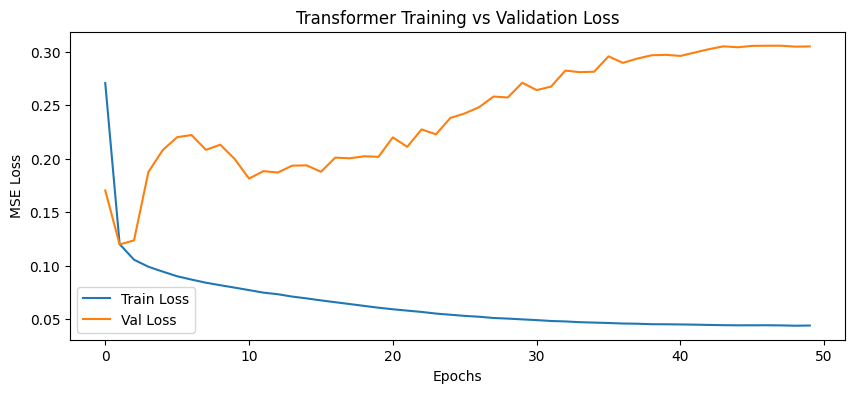

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Transformer Training vs Validation Loss')
plt.legend()
plt.savefig('transformer_training_curves.png')
plt.show()

we'll now evaluate the transformer for later comp. with our lsmt.

In [13]:
# Load best weights
model.load_state_dict(torch.load('transformer_weights.pth'))
model.eval()

all_preds, all_targets = [], []

start_inference = time.time()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        output = model(x_batch)
        all_preds.append(output.cpu().numpy())
        all_targets.append(y_batch.numpy())
inference_time = time.time() - start_inference

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Inverse transform to actual temperature
all_preds_actual = all_preds * temp_std + temp_mean
all_targets_actual = all_targets * temp_std + temp_mean

# Metrics
mae = mean_absolute_error(all_targets_actual.flatten(), all_preds_actual.flatten())
rmse = np.sqrt(mean_squared_error(all_targets_actual.flatten(), all_preds_actual.flatten()))
print(f'Test MAE:  {mae:.4f} °C')
print(f'Test RMSE: {rmse:.4f} °C')
print(f'Inference time on test set: {inference_time:.2f} seconds')

Test MAE:  2.0580 °C
Test RMSE: 2.6753 °C
Inference time on test set: 10.70 seconds


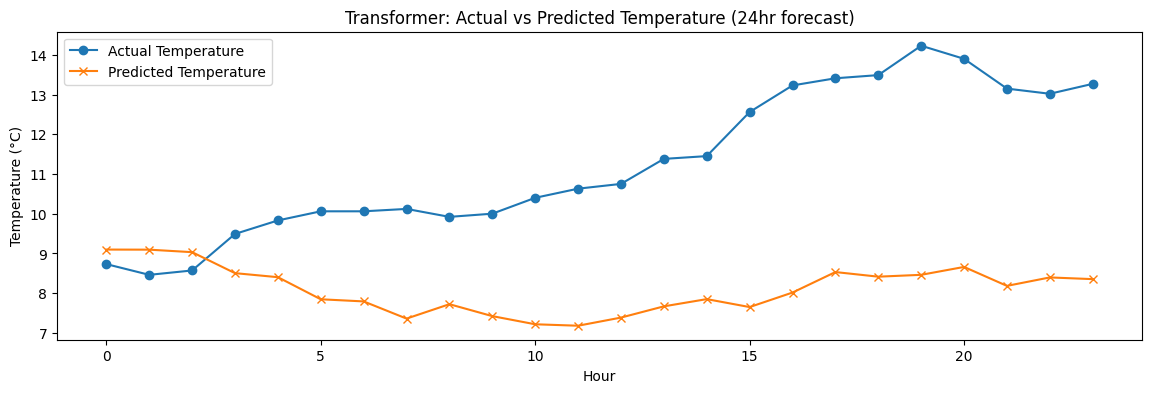

In [14]:
sample_idx = 0
plt.figure(figsize=(14, 4))
plt.plot(all_targets_actual[sample_idx], label='Actual Temperature', marker='o')
plt.plot(all_preds_actual[sample_idx], label='Predicted Temperature', marker='x')
plt.xlabel('Hour')
plt.ylabel('Temperature (°C)')
plt.title('Transformer: Actual vs Predicted Temperature (24hr forecast)')
plt.legend()
plt.savefig('transformer_preds.png')
plt.show()

In [15]:
np.save('transformer_preds.npy', all_preds_actual)
np.save('transformer_targets.npy', all_targets_actual)

transformer_metadata = {
    'mae': mae,
    'rmse': rmse,
    'training_time_sec': total_training_time,
    'inference_time_sec': inference_time,
    'num_parameters': sum(p.numel() for p in model.parameters()),
}

import json
with open('transformer_metadata.json', 'w') as f:
    json.dump(transformer_metadata, f, indent=4)

print('Transformer predictions and metadata saved.')
print(transformer_metadata)

Transformer predictions and metadata saved.
{'mae': 2.0579581260681152, 'rmse': np.float64(2.675319927015), 'training_time_sec': 7846.777637481689, 'inference_time_sec': 10.69687032699585, 'num_parameters': 151896}
